In [1]:
import illoominate
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
train_df = pd.read_csv('data/nowplaying1m/processed/train.csv', sep='\t')
validation_df = pd.read_csv('data/nowplaying1m/processed/valid.csv', sep='\t')

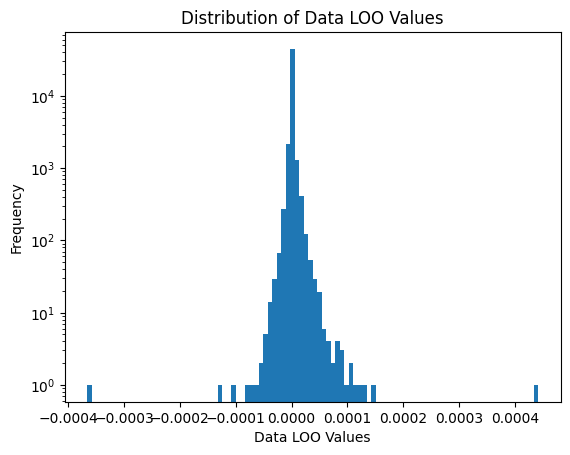

In [3]:
loo_values = illoominate.data_loo_values(
    train_df=train_df,
    validation_df=validation_df,
    model='vmis',
    metric='mrr@20',
    params={'m':100, 'k':100, 'seed': 42},
)

plt.hist(loo_values['score'], density=False, bins=100)
plt.title('Distribution of Data LOO Values')
plt.yscale('log')
plt.ylabel('Frequency')
plt.xlabel('Data LOO Values')
plt.savefig('images/loo.png', dpi=300)
plt.show()


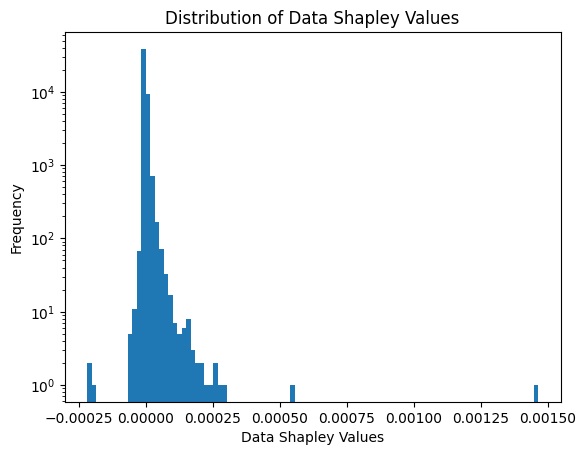

In [4]:
shapley_values = illoominate.data_shapley_values(
    train_df=train_df,
    validation_df=validation_df,
    model='vmis',
    metric='mrr@20',
    params={'m':100, 'k':100, 'seed': 42, 'convergence_threshold': 2000},
)


plt.hist(shapley_values['score'], density=False, bins=100)
plt.title('Distribution of Data Shapley Values')
plt.yscale('log')
plt.ylabel('Frequency')
plt.xlabel('Data Shapley Values')
plt.savefig('images/shapley.png', dpi=300)
plt.show()


In [5]:
negative = shapley_values[shapley_values.score < 0]
corrupt_sessions = train_df.merge(negative, on='session_id')
corrupt_sessions

,session_id,item_id,timestamp,score
0,0,0,1388710565,-5.548310e-06
1,0,13,1388710928,-5.548310e-06
2,0,28,1388711284,-5.548310e-06
3,0,80,1388712726,-5.548310e-06
4,0,100,1388713444,-5.548310e-06
...,...,...,...,...
264372,48959,1681,1411462022,-2.752243e-08
264373,48959,1936,1411462742,-2.752243e-08
264374,48959,42416,1411463102,-2.752243e-08
264375,48959,68637,1411463462,-2.752243e-08
